In [1]:
# Want to make sure least squares wouldn't have worked for MQ24 framework

In [1]:
import numpy as np
from astropy.cosmology import Planck15
from scipy.optimize import curve_fit
import thermalsyn_v2 as thermalsyn
import Constants as C
from astropy.table import Table
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import math
import scipy.stats
import pandas as pd
from astropy.cosmology import Planck18

In [2]:
def AT2024wpp(epoch):

    color = "#ffa600"
    name = "24wpp"
    filename = "../../data/whippet_radio.txt"
    data = pd.read_csv(filename, sep="\t", skiprows=1, names=[
           "FBOTName", "dt_days", "nu_GHz", "flux_mJy", "ferr_mJy", "rms_mJy",
           "det", "reference", "obs", "timestart", "timestop", "tmid"])
    Days = data['dt_days'].values # days
    Freq = data['nu_GHz'].values * 1e9 # Hz
    Flux = data['flux_mJy'].values * 1e-3 # Jy 
    eFlux = data['ferr_mJy'].values * 1e-3 # Jy

    #Inclusion of Nayana's ALMA data
    nDays = [18.92, 18.89, 35.76, 35.79]; nFreq = [97.5e9, 203.0e9, 97.5e9, 203.0e9]
    nFlux = [0.000076, 0.000100, 0.001282, 0.000588]; neFlux = [0.000019, 0.000024, 0.000015, 0.000031] # Jy
    Days = np.append(Days, nDays); Freq = np.append(Freq, nFreq)
    Flux = np.append(Flux, nFlux); eFlux = np.append(eFlux, neFlux)

    epochGroups = [
        #[12.02],
        [12.02, 18.92, 18.89], # Added extra ALMA data
        #[28.91,32.9,36.653,33.684,34.714],
        [28.91,32.9,36.653,33.684,34.714,35.76,35.79], # Added extra ALMA data
        [43.88,43.611,43.628,43.670],
        [70.78,71.596,71.614,71.702],
        [110.70, 113.445, 128.65],
        [191.5],
        #[298.25]
    ]

    epochIndex = epoch - 1
    group = np.array(epochGroups[epochIndex])
    tMask = np.any(np.isclose(Days[:, None], group[None, :], rtol=0, atol=1e-3), axis=1)
    freq = Freq[tMask]
    flux = Flux[tMask]
    fluxErr = eFlux[tMask]
    
    # Known info
    T = np.mean(Days[tMask]) # Time (days) of observation in observer's frame
    z = 0.0868 # Source redshift
    d_L = Planck18.luminosity_distance(z).cgs.value # Luminosity distance (cm)

    return T, z, d_L, freq, flux, fluxErr

bG_sh: 2.099999999976126
Mdot_power_fit: -4.000000000046375
epsilon_B: 0.19999999999559065


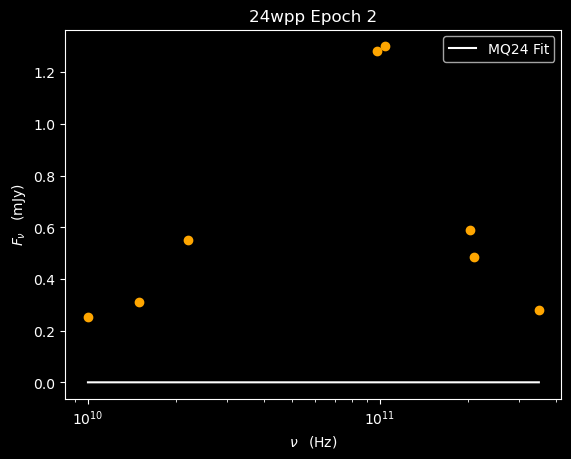

In [17]:
# Kitbashing old MQ24 code

epoch = 2
T, z, d_L, freq, flux, fluxErr = AT2024wpp(epoch)

freqfit = np.logspace(np.log10(min(freq)),np.log10(max(freq)),100) # Hz

# Way to do it from MQ24
epsilon_T = 0.4
#epsilon_B = 0.1
epsilon_e = 0.1
p = 3
f = 3.0/16.0
ell_dec = 1.0
bounds = ([0.1, -6, 1e-2], [2.1, -4, 0.2])
def fit_func(nu, bG_sh, Mdot, epsilon_B):
    Fnu = np.log10(thermalsyn.Fnu_of_nu(bG_sh,10**Mdot*(C.Msun/C.yr/1e8),10**nu,T,
                                        Dlum=d_L,z=z,include_syn_cooling=False,
                                        epsilon_T=epsilon_T,epsilon_B=epsilon_B,
                                        epsilon_e=epsilon_e,p=p,f=f,ell_dec=ell_dec))
    return Fnu

popt, pcov = curve_fit(fit_func,np.log10(freq*(1+z)),np.log10(flux*C.Jy), bounds=bounds)

# best fit shock velocity and mass-loss rates
bG_sh_fit = popt[0]
Mdot_power_fit = popt[1]
Mdot_fit = 10**popt[1]*(C.Msun/C.yr/1e8)
epsilon_B = popt[2]

print("bG_sh: {}".format(bG_sh_fit))
print("Mdot_power_fit: {}".format(Mdot_power_fit))
print("epsilon_B: {}".format(epsilon_B))

# generate SED from the the best-fit model
Fnu_fit = thermalsyn.Fnu_of_nu(bG_sh_fit,Mdot_fit,freqfit*(1+z),T,
                               Dlum=d_L,z=z,include_syn_cooling=False,
                               epsilon_T=epsilon_T,epsilon_B=epsilon_B,
                               epsilon_e=epsilon_e,p=p,f=f,ell_dec=ell_dec) # ergs/cm^2/s/Hz

plt.plot(freqfit, Fnu_fit/C.Jy*(1E3), c="white", label="MQ24 Fit") # Hz, mJy

color = "#ffa600"
plt.scatter(freq, flux*1E3, c=color) # Hz, mJy

plt.legend()
plt.title('24wpp Epoch {}'.format(epoch))
plt.xlabel(r'$\nu \,\,\,\,\, ({\rm Hz})$')
plt.ylabel(r'$F_\nu \,\,\,\,\, ({\rm mJy})$')
plt.xscale("log")
plt.show()

bG_sh: 2.0999999999999965
log10(Mdot): -4.0000000000000036
epsilon_B: 0.19999999999999954
chi2 (approx): 3311431.472892512
dof: 5


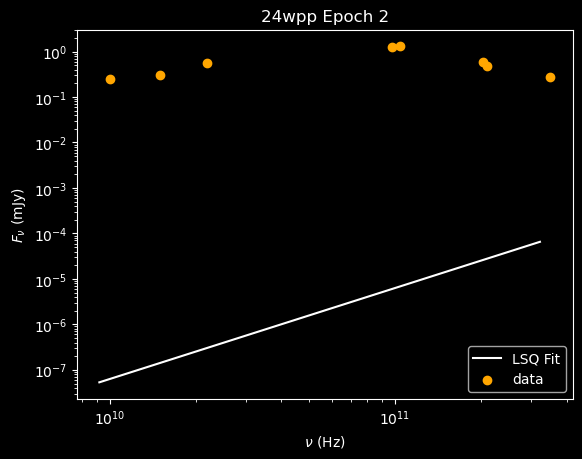

In [19]:
# using least squares

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

epoch = 2
T, z, d_L, freq, flux, fluxErr = AT2024wpp(epoch)

# frequency grid for plotting
freqfit = np.geomspace(freq.min(), freq.max(), 200)  # Hz

# MQ24-ish constants
epsilon_T = 0.4
epsilon_e = 0.1
p = 3
f = 3.0/16.0
ell_dec = 1.0

# bounds in theta-space: [bG_sh, log10_Mdot, epsilon_B]
lb = np.array([0.1, -6.0, 1e-2])
ub = np.array([2.1, -4.0, 0.2])

# data in log-space
x = np.log10(freq)                     # log10 nu_obs
y = np.log10(flux * C.Jy)              # log10(Fnu) in cgs units

# log-space uncertainties (avoid divide-by-zero)
mask = (flux > 0) & (fluxErr > 0) & np.isfinite(freq) & np.isfinite(flux) & np.isfinite(fluxErr)
x = x[mask]
y = y[mask]
flux_m = flux[mask]
fluxErr_m = fluxErr[mask]

sigma_y = (fluxErr_m / flux_m) / np.log(10)  # approx sigma(log10 F)
sigma_y = np.clip(sigma_y, 1e-3, np.inf)     # optional floor to avoid insane weights

def model_logF(theta, log10_nu_obs):
    bG_sh, log10_Mdot, epsilon_B = theta
    nu_obs = 10**log10_nu_obs
    mdot = 10**log10_Mdot * (C.Msun / C.yr / 1e8)

    Fnu = thermalsyn.Fnu_of_nu(
        bG_sh, mdot, nu_obs, T,
        Dlum=d_L, z=z, include_syn_cooling=False,
        epsilon_T=epsilon_T, epsilon_B=epsilon_B,
        epsilon_e=epsilon_e, p=p, f=f, ell_dec=ell_dec
    )
    return np.log10(Fnu)

def residuals(theta):
    # weighted residuals in log space
    return (model_logF(theta, x) - y) / sigma_y

# initial guess (pick something inside bounds)
theta0 = np.array([0.5, -5.0, 0.05])

res = least_squares(
    residuals,
    theta0,
    bounds=(lb, ub),
    method="trf",          # default; supports bounds
    loss="linear"          # change to "soft_l1" or "huber" if you want robustness
)

bG_sh_fit, log10_Mdot_fit, epsilon_B_fit = res.x
Mdot_fit = 10**log10_Mdot_fit * (C.Msun / C.yr / 1e8)

print("bG_sh:", bG_sh_fit)
print("log10(Mdot):", log10_Mdot_fit)
print("epsilon_B:", epsilon_B_fit)
print("chi2 (approx):", np.sum(res.fun**2))
print("dof:", len(y) - len(res.x))

# best-fit curve
Fnu_fit = thermalsyn.Fnu_of_nu(
    bG_sh_fit, Mdot_fit, freqfit, T,
    Dlum=d_L, z=z, include_syn_cooling=False,
    epsilon_T=epsilon_T, epsilon_B=epsilon_B_fit,
    epsilon_e=epsilon_e, p=p, f=f, ell_dec=ell_dec
)

plt.plot(freqfit, Fnu_fit / C.Jy * 1e3, c="white", label="LSQ Fit")  # mJy
plt.scatter(freq, flux*1e3, c="#ffa600", label="data")            # mJy, if you want

plt.legend()
plt.title(f"24wpp Epoch {epoch}")
plt.xlabel(r'$\nu \,\, ({\rm Hz})$')
plt.ylabel(r'$F_\nu \,\, ({\rm mJy})$')
plt.xscale("log")
plt.yscale("log")  # usually useful for SEDs; remove if you don't want
plt.show()


/Users/michaelcamilo/research/project_Thermal/driver/thermal_synchrotron_v2/thermalsyn_v2.py:161: RuntimeWarning: divide by zero encountered in scalar divide
  return 2.0*Theta**2/special.kn(2,1.0/Theta)
/Users/michaelcamilo/research/project_Thermal/driver/thermal_synchrotron_v2/thermalsyn_v2.py:771: RuntimeWarning: invalid value encountered in multiply
  I = I_of_x(x)*f_fun(Theta)
/Users/michaelcamilo/research/project_Thermal/driver/thermal_synchrotron_v2/thermalsyn_v2.py:783: RuntimeWarning: overflow encountered in multiply
  Lnu = L_tilde*( x*I*cooling_correction_th + a*x**(-0.5*(p-1.0))*a_corr*cooling_correction_pl )*tau_fun


bG_sh: 2.0999999999999996
log10(Mdot): -4.501704725036703  -> Mdot: 19862979038484.848
eps_B: 0.1717504534467015
eps_T: 1.0
eps_e: 1.000000000000002e-06
chi2 ~ 2866313.8278063843    dof = 3


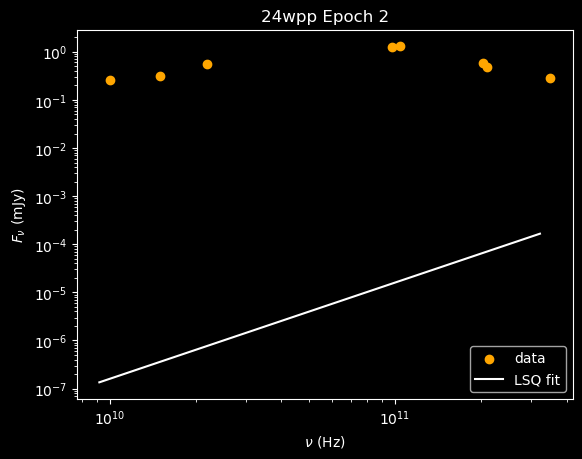

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

epoch = 2
T, z, d_L, freq, flux, fluxErr = AT2024wpp(epoch)

# plot grid
freqfit = np.geomspace(freq.min(), freq.max(), 300)

# fixed physics
p = 3
f = 3.0/16.0
ell_dec = 1.0

# ----- data prep -----
mask = (freq > 0) & (flux > 0) & (fluxErr > 0) & np.isfinite(freq) & np.isfinite(flux) & np.isfinite(fluxErr)
freq_m = freq[mask]
flux_m = flux[mask]
fluxErr_m = fluxErr[mask]

x = np.log10(freq_m)               # log10(nu_obs)
y = np.log10(flux_m * C.Jy)        # log10(Fnu) in cgs

# log-space sigma: sigma_logF ~ (sigma_F/F)/ln10
sigma_y = (fluxErr_m / flux_m) / np.log(10)
sigma_y = np.clip(sigma_y, 1e-3, np.inf)   # optional floor

def model_logF(theta, log10_nu_obs):
    bG_sh, log10_Mdot, log10_epsB, log10_epsT, log10_epsE = theta
    nu_obs = 10**log10_nu_obs

    mdot = 10**log10_Mdot * (C.Msun / C.yr / 1e8)
    epsB = 10**log10_epsB
    epsT = 10**log10_epsT
    epsE = 10**log10_epsE

    Fnu = thermalsyn.Fnu_of_nu(
        bG_sh, mdot, nu_obs, T,
        Dlum=d_L, z=z, include_syn_cooling=False,
        epsilon_T=epsT, epsilon_B=epsB,
        epsilon_e=epsE, p=p, f=f, ell_dec=ell_dec
    )
    return np.log10(Fnu)

def residuals(theta):
    return (model_logF(theta, x) - y) / sigma_y

# ----- bounds -----
# bG_sh in [0.1, 2.1]
# log10(Mdot) in [-6, -4]  (your choice)
# eps bounds (very common): 1e-6 .. 1
lb = np.array([0.1,  -6.0, -6.0, -6.0, -6.0])
ub = np.array([2.1,  -4.0,  0.0,  0.0,  0.0])

# ----- multistart (important when you add params) -----
rng = np.random.default_rng(0)

def random_theta0():
    # uniform in bounds (log params already)
    return lb + (ub - lb) * rng.random(len(lb))

best = None
for _ in range(50):  # bump to 200 if you want
    theta0 = random_theta0()
    res = least_squares(residuals, theta0, bounds=(lb, ub), method="trf", loss="linear")
    if (best is None) or (res.cost < best.cost):
        best = res

bG_sh_fit, log10_Mdot_fit, log10_epsB_fit, log10_epsT_fit, log10_epsE_fit = best.x
Mdot_fit = 10**log10_Mdot_fit * (C.Msun / C.yr / 1e8)
epsB_fit = 10**log10_epsB_fit
epsT_fit = 10**log10_epsT_fit
epsE_fit = 10**log10_epsE_fit

print("bG_sh:", bG_sh_fit)
print("log10(Mdot):", log10_Mdot_fit, " -> Mdot:", Mdot_fit)
print("eps_B:", epsB_fit)
print("eps_T:", epsT_fit)
print("eps_e:", epsE_fit)
print("chi2 ~", np.sum(best.fun**2), "   dof =", len(y) - len(best.x))

# ----- best-fit curve -----
Fnu_fit = thermalsyn.Fnu_of_nu(
    bG_sh_fit, Mdot_fit, freqfit, T,
    Dlum=d_L, z=z, include_syn_cooling=False,
    epsilon_T=epsT_fit, epsilon_B=epsB_fit,
    epsilon_e=epsE_fit, p=p, f=f, ell_dec=ell_dec
)

plt.scatter(freq_m, flux_m*1e3, c="#ffa600", label="data")      # mJy
plt.plot(freqfit, (Fnu_fit / C.Jy)*1e3, c="white", label="LSQ fit")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r'$\nu\ \mathrm{(Hz)}$')
plt.ylabel(r'$F_\nu\ \mathrm{(mJy)}$')
plt.title(f"24wpp Epoch {epoch}")
plt.legend()
plt.show()


/Users/michaelcamilo/research/project_Thermal/driver/thermal_synchrotron_v2/thermalsyn_v2.py:161: RuntimeWarning: divide by zero encountered in scalar divide
  return 2.0*Theta**2/special.kn(2,1.0/Theta)
/Users/michaelcamilo/research/project_Thermal/driver/thermal_synchrotron_v2/thermalsyn_v2.py:771: RuntimeWarning: invalid value encountered in multiply
  I = I_of_x(x)*f_fun(Theta)
/Users/michaelcamilo/research/project_Thermal/driver/thermal_synchrotron_v2/thermalsyn_v2.py:783: RuntimeWarning: overflow encountered in multiply
  Lnu = L_tilde*( x*I*cooling_correction_th + a*x**(-0.5*(p-1.0))*a_corr*cooling_correction_pl )*tau_fun


bG_sh: 2.0999999999999996
log10(Mdot): -4.067571993685236  -> Mdot: 53973069267575.914
eps_B: 0.04218264711641566  eps_T: 1.0  eps_e: 1.0000000042031538e-06
f: 0.20527945876269602
chi2 ~ 2866313.827806223    dof = 2


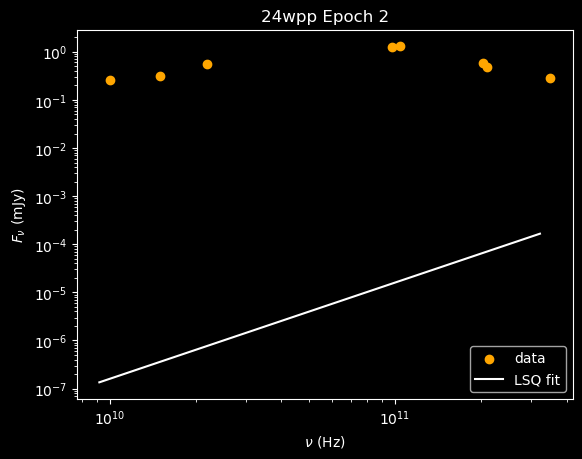

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

epoch = 2
T, z, d_L, freq, flux, fluxErr = AT2024wpp(epoch)

freqfit = np.geomspace(freq.min(), freq.max(), 300)

# fixed physics
p = 3
ell_dec = 1.0

# ---- data prep ----
mask = (freq > 0) & (flux > 0) & (fluxErr > 0) & np.isfinite(freq) & np.isfinite(flux) & np.isfinite(fluxErr)
freq_m = freq[mask]
flux_m = flux[mask]
fluxErr_m = fluxErr[mask]

x = np.log10(freq_m)
y = np.log10(flux_m * C.Jy)

sigma_y = (fluxErr_m / flux_m) / np.log(10)
sigma_y = np.clip(sigma_y, 1e-3, np.inf)

def model_logF(theta, log10_nu_obs):
    bG_sh, log10_Mdot, log10_epsB, log10_epsT, log10_epsE, log10_f = theta
    nu_obs = 10**log10_nu_obs

    mdot = 10**log10_Mdot * (C.Msun / C.yr / 1e8)
    epsB = 10**log10_epsB
    epsT = 10**log10_epsT
    epsE = 10**log10_epsE
    fval = 10**log10_f

    Fnu = thermalsyn.Fnu_of_nu(
        bG_sh, mdot, nu_obs, T,
        Dlum=d_L, z=z, include_syn_cooling=False,
        epsilon_T=epsT, epsilon_B=epsB,
        epsilon_e=epsE, p=p, f=fval, ell_dec=ell_dec
    )
    return np.log10(Fnu)

def residuals(theta):
    return (model_logF(theta, x) - y) / sigma_y

# ---- bounds ----
# bG_sh, log10Mdot, log10 epsB, log10 epsT, log10 epsE, log10 f
lb = np.array([0.1,  -6.0, -6.0, -6.0, -6.0, -3.0])  # f >= 1e-3
ub = np.array([2.1,  -4.0,  0.0,  0.0,  0.0,  0.0])  # f <= 1

# ---- multistart ----
rng = np.random.default_rng(0)

def random_theta0():
    return lb + (ub - lb) * rng.random(len(lb))

best = None
for _ in range(100):
    theta0 = random_theta0()
    res = least_squares(residuals, theta0, bounds=(lb, ub), method="trf", loss="linear")
    if (best is None) or (res.cost < best.cost):
        best = res

bG_sh_fit, log10_Mdot_fit, log10_epsB_fit, log10_epsT_fit, log10_epsE_fit, log10_f_fit = best.x

Mdot_fit = 10**log10_Mdot_fit * (C.Msun / C.yr / 1e8)
epsB_fit = 10**log10_epsB_fit
epsT_fit = 10**log10_epsT_fit
epsE_fit = 10**log10_epsE_fit
f_fit   = 10**log10_f_fit

print("bG_sh:", bG_sh_fit)
print("log10(Mdot):", log10_Mdot_fit, " -> Mdot:", Mdot_fit)
print("eps_B:", epsB_fit, " eps_T:", epsT_fit, " eps_e:", epsE_fit)
print("f:", f_fit)
print("chi2 ~", np.sum(best.fun**2), "   dof =", len(y) - len(best.x))

# ---- plot best-fit curve ----
Fnu_fit = thermalsyn.Fnu_of_nu(
    bG_sh_fit, Mdot_fit, freqfit, T,
    Dlum=d_L, z=z, include_syn_cooling=False,
    epsilon_T=epsT_fit, epsilon_B=epsB_fit,
    epsilon_e=epsE_fit, p=p, f=f_fit, ell_dec=ell_dec
)

plt.scatter(freq_m, flux_m*1e3, c="#ffa600", label="data")
plt.plot(freqfit, (Fnu_fit/C.Jy)*1e3, c="white", label="LSQ fit")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r'$\nu\ \mathrm{(Hz)}$'); plt.ylabel(r'$F_\nu\ \mathrm{(mJy)}$')
plt.title(f"24wpp Epoch {epoch}")
plt.legend()
plt.show()


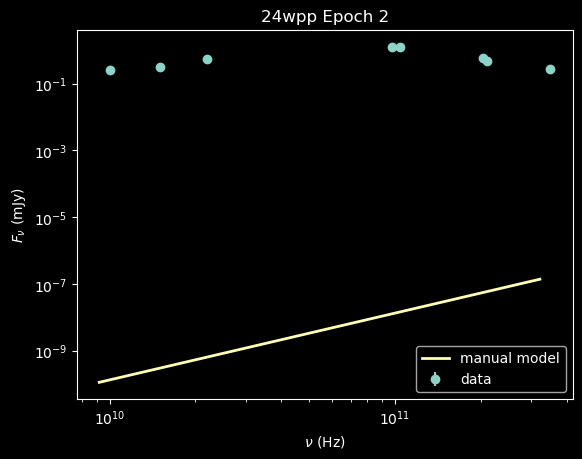

In [5]:
import numpy as np
import matplotlib.pyplot as plt

epoch = 2
T, z, d_L, freq, flux, fluxErr = AT2024wpp(epoch)

# -----------------------------
# USER INPUTS (6 free params)
# -----------------------------
bG_sh      = 0.5          # shock proper velocity (example)
log10_Mdot = 13.166         # log10 of the Mdot "power" you're using
epsB       = 0.174         # epsilon_B
epsT       = 0.460          # epsilon_T
epsE       = 0.363          # epsilon_e
fval       = 0.010     # f
p          = 3.0          # if you want p fixed here
ell_dec    = 1.0          # fixed

# Convert to whatever thermalsyn expects for Mdot in your code
Mdot = 10**log10_Mdot * (C.Msun / C.yr / 1e8)

# freq grid for plotting
freqfit = np.geomspace(freq.min(), freq.max(), 300)

# Model prediction
Fnu_model = thermalsyn.Fnu_of_nu(
    bG_sh, Mdot, freqfit, T,
    Dlum=d_L, z=z, include_syn_cooling=False,
    epsilon_T=epsT, epsilon_B=epsB,
    epsilon_e=epsE, p=p, f=fval, ell_dec=ell_dec
)

# Convert to mJy for plotting
Fnu_model_mJy = (Fnu_model / C.Jy) * 1e3
flux_mJy = flux * 1e3
fluxErr_mJy = fluxErr * 1e3

# Plot
plt.figure()
plt.errorbar(freq, flux_mJy, yerr=fluxErr_mJy, fmt='o', ms=6, label='data')
plt.plot(freqfit, Fnu_model_mJy, lw=2, label='manual model')

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r'$\nu\ \mathrm{(Hz)}$')
plt.ylabel(r'$F_\nu\ \mathrm{(mJy)}$')
plt.title(f"24wpp Epoch {epoch}")
plt.legend()
plt.show()


In [ ]:
# yuuuup i need to confirm my units are right. it shouldn't look this way